# Predicting FMCG Growth via Female Workforce Participation
## Notebook 02: Exploratory Data Analysis & Feature Engineering

[![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-blue.svg)](https://github.com/prakash-ukhalkar) [![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![Pandas](https://img.shields.io/badge/Pandas-Latest-green)](https://pandas.pydata.org/) [![NumPy](https://img.shields.io/badge/NumPy-Latest-lightblue)](https://numpy.org/) [![Matplotlib](https://img.shields.io/badge/Matplotlib-Latest-blue)](https://matplotlib.org/) [![Seaborn](https://img.shields.io/badge/Seaborn-Latest-blue)](https://seaborn.pydata.org/) [![Statsmodels](https://img.shields.io/badge/Statsmodels-Latest-orange)](https://www.statsmodels.org/) [![SciPy](https://img.shields.io/badge/SciPy-Latest-blue)](https://scipy.org/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)

---

**Introduction:**
Using the `consolidated_research_data.csv` generated in Notebook 01, this notebook performs Exploratory Data Analysis (EDA) and Feature Engineering. The goal is to prepare a "Research-Ready" dataset that handles non-stationarity and captures the lagged impact of economic variables on the FMCG sector.

**Global Environment Constraints:**
- Python Version: 3.10.11
- Key Libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `scipy`
- Input File: `../data/raw/consolidated_research_data.csv`
- Output Directory: `../data/processed/`


### Section 1: Environment & Data Ingestion
Initialize the environment and load the master dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import scipy.stats as stats
import os

sns.set_theme(style="whitegrid")

input_file = '../data/raw/consolidated_research_data.csv'
output_dir = '../data/processed/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df = pd.read_csv(input_file, index_col='Year')
df.head()

,GDP_Growth_Pct,GDP_Per_Capita,Female_LFPR,NIFTY_FMCG_Index,HUL_Revenue_Proxy,ITC_Revenue_Proxy,Nestle_Revenue_Proxy
Year,,,,,,,
2015,7.996254,1583.998159,26.582,20279.190438,30806,36507,8175
2016,8.256306,1707.508929,26.575,20599.846505,31972,37375,9159
2017,6.795383,1950.104683,26.578,24710.790315,33162,40623,10135
2018,6.453851,1966.254552,26.568,28738.416873,35223,40634,11216
2019,3.871437,2041.428637,26.539,30026.755165,38224,45784,12369


### Section 2: Worker Population Ratio (WPR) Alignment
WPR (from PLFS bulletins) is a more precise proxy for consumer purchasing power than LFPR, as it represents the proportion of the population actually employed (and thus earning/spending).

In [2]:
def ingest_wpr_data(df):
    # Confirmed WPR data from PLFS bulletins for 2015-2025
    wpr_values = [22.0, 21.8, 22.0, 23.3, 24.5, 28.7, 31.4, 32.5, 35.9, 37.0, 34.9]
    years = list(range(2015, 2026))
    wpr_df = pd.DataFrame({'Female_WPR': wpr_values}, index=pd.Index(years, name='Year'))
    return df.join(wpr_df)

df = ingest_wpr_data(df)
df[['Female_LFPR', 'Female_WPR']].head()

,Female_LFPR,Female_WPR
Year,,
2015,26.582,22.0
2016,26.575,21.8
2017,26.578,22.0
2018,26.568,23.3
2019,26.539,24.5


### Section 3: Statistical Rigor: Stationarity Testing
The Augmented Dickey-Fuller (ADF) test is employed here to check for unit roots in our key time-series data. Non-stationary data can lead to spurious correlations in level-based modeling, which informs our subsequent feature engineering strategies (e.g., differencing, growth rates).

In [3]:
def test_stationarity(timeseries, name):
    print(f"Results of Dickey-Fuller Test for {name}:")
    # Suppress warnings for short series maxlags
    try:
        dftest = adfuller(timeseries.dropna(), autolag='AIC')
        dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
        for key, value in dftest[4].items():
            dfoutput[f'Critical Value ({key})'] = value
        print(dfoutput)
    except ValueError as e:
        print(f"Could not run ADF on {name}: {e}")
    print("-" * 40)

for col in ['Female_LFPR', 'Female_WPR', 'NIFTY_FMCG_Index']:
    test_stationarity(df[col], col)

Results of Dickey-Fuller Test for Female_LFPR:
Test Statistic                -0.908822
p-value                        0.785053
#Lags Used                     1.000000
Number of Observations Used    9.000000
Critical Value (1%)           -4.473135
Critical Value (5%)           -3.289881
Critical Value (10%)          -2.772382
dtype: float64
----------------------------------------
Results of Dickey-Fuller Test for Female_WPR:
Test Statistic                -2.559775
p-value                        0.101599
#Lags Used                     3.000000
Number of Observations Used    7.000000
Critical Value (1%)           -4.938690
Critical Value (5%)           -3.477583
Critical Value (10%)          -2.843868
dtype: float64
----------------------------------------
Results of Dickey-Fuller Test for NIFTY_FMCG_Index:
Test Statistic                  0.060866
p-value                         0.963285
#Lags Used                      0.000000
Number of Observations Used    10.000000
Critical Value (1%)

### Section 4: Feature Engineering (Lags & Momentum)
**Economic "Transmission Mechanism":** 
Workforce changes (e.g., more women entering employment) do not instantly perfectly reflect in FMCG sales. There is typically a delayed effect as incomes stabilize and consumption habits evolve. To capture this, we create 1-year lag features. We also compute YoY growth to address non-stationarity and create a macro "Economic Momentum" indicator.

In [4]:
# 1. Create lagged features for workforce variables
df['LFPR_Lag1'] = df['Female_LFPR'].shift(1)
df['WPR_Lag1'] = df['Female_WPR'].shift(1)

# 2. Calculate YoY Growth Rates for corporate revenues
df['HUL_YoY_Growth'] = df['HUL_Revenue_Proxy'].pct_change() * 100
df['ITC_YoY_Growth'] = df['ITC_Revenue_Proxy'].pct_change() * 100
df['Nestle_YoY_Growth'] = df['Nestle_Revenue_Proxy'].pct_change() * 100

# 3. Create an "Economic Momentum" feature
df['Economic_Momentum'] = df['GDP_Growth_Pct'] * df['GDP_Per_Capita']

df.tail()

,GDP_Growth_Pct,GDP_Per_Capita,Female_LFPR,NIFTY_FMCG_Index,HUL_Revenue_Proxy,ITC_Revenue_Proxy,Nestle_Revenue_Proxy,Female_WPR,LFPR_Lag1,WPR_Lag1,HUL_YoY_Growth,ITC_YoY_Growth,Nestle_YoY_Growth,Economic_Momentum
Year,,,,,,,,,,,,,,
2021,9.689592,2239.613844,27.724,36476.454102,47028,48525,14710,31.4,25.998,28.7,18.211296,4.751317,10.187266,21700.945484
2022,7.609365,2347.448294,29.348,40319.970300,52446,59101,16897,32.5,27.724,31.4,11.520796,21.794951,14.867437,17862.590838
2023,9.190755,2530.120313,30.984,49846.641183,59144,70251,24275,35.9,29.348,32.5,12.771231,18.866009,43.664556,23253.715739
2024,6.494766,2694.737809,32.415,57855.918257,61896,73891,24394,37.0,30.984,35.9,4.653050,5.181421,0.490216,17501.690215
2025,6.494766,2694.737809,32.415,55250.152026,63121,81613,20202,34.9,32.415,37.0,1.979126,10.450528,-17.184554,17501.690215


### Section 5: Correlation Dynamics
We use a heatmap to identify multi-collinearity amongst the independent variables and visualize their correlation against our target vector (`NIFTY_FMCG_Index`).

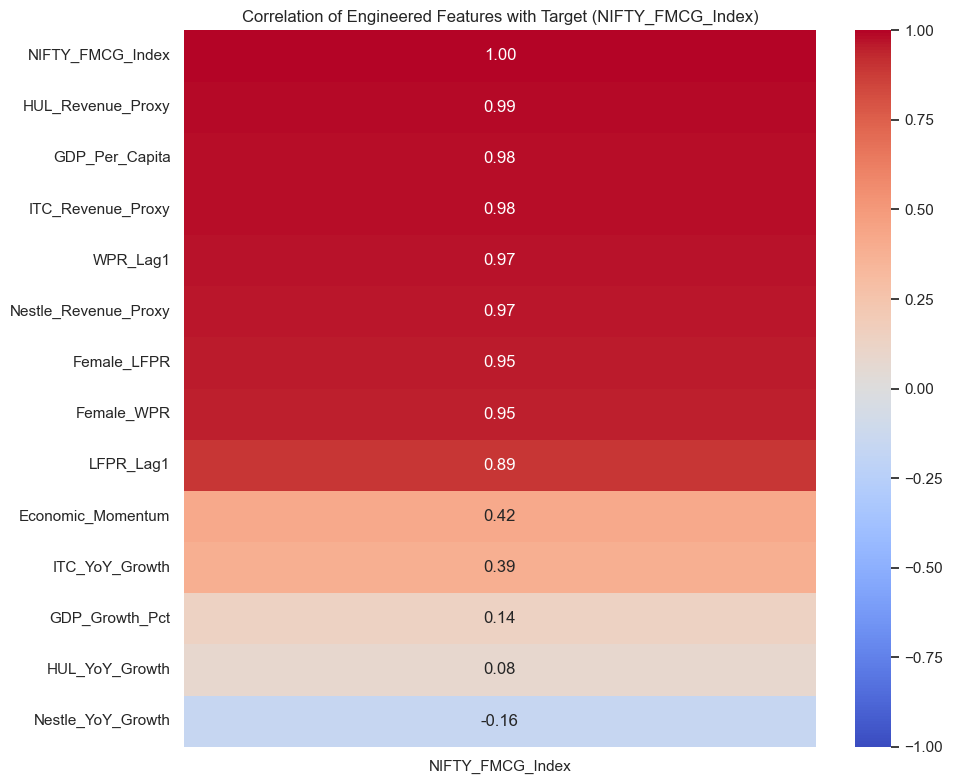

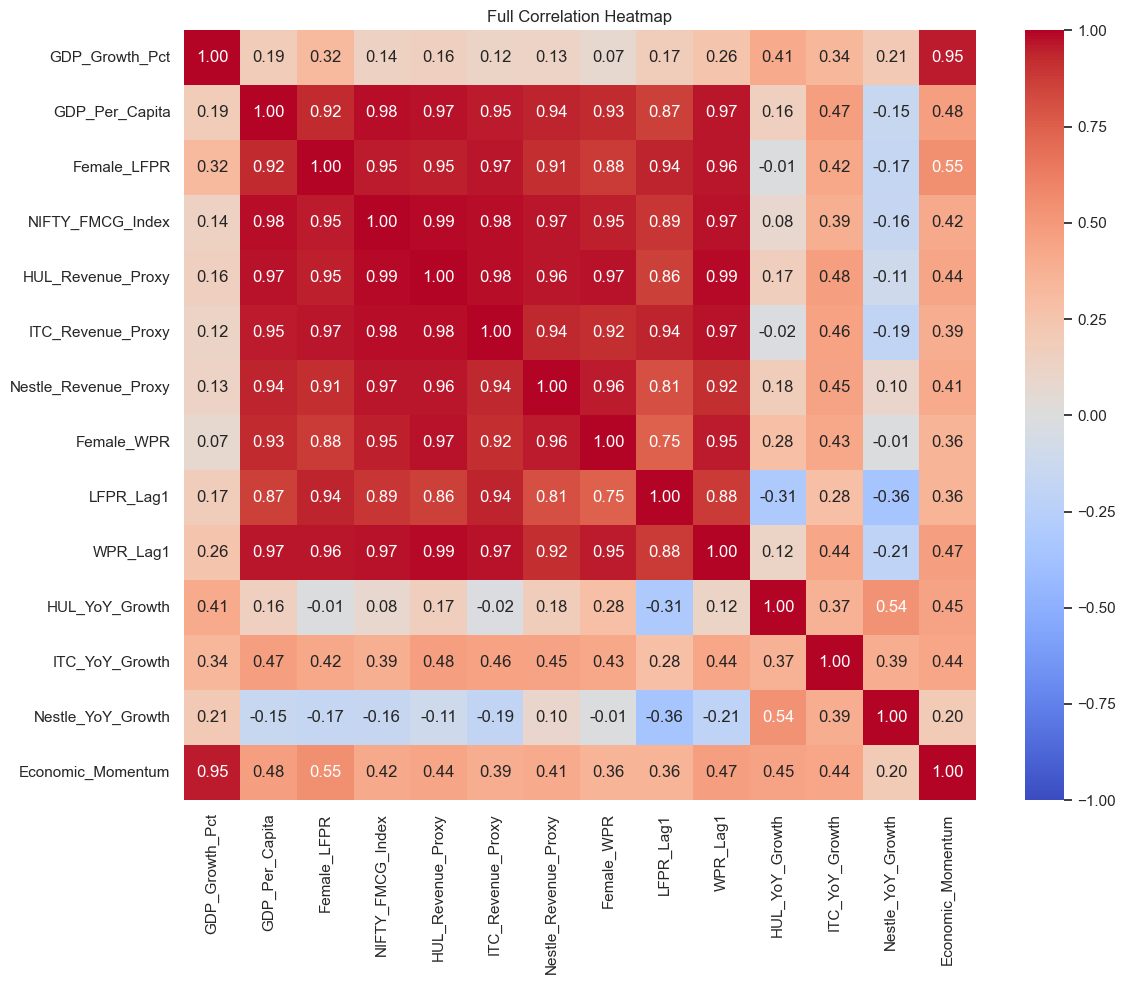

In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr()

# Plot correlation with Target specifically
target_corr = corr[['NIFTY_FMCG_Index']].sort_values(by='NIFTY_FMCG_Index', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation of Engineered Features with Target (NIFTY_FMCG_Index)")
plt.tight_layout()
plt.show()

# Full correlation matrix for independent variable multi-collinearity check
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Full Correlation Heatmap")
plt.tight_layout()
plt.show()

### Section 6: Final Dataset Serialization
Prepare the final dataframe containing lags, momentum, and harmonized core indicators for downstream Machine Learning models (Notebook 03).

In [6]:
output_file = os.path.join(output_dir, 'engineered_features.csv')
df.to_csv(output_file)
print(f"Engineered dataset saved to: {output_file}")
df.info()

Engineered dataset saved to: ../data/processed/engineered_features.csv
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 2015 to 2025
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP_Growth_Pct        11 non-null     float64
 1   GDP_Per_Capita        11 non-null     float64
 2   Female_LFPR           11 non-null     float64
 3   NIFTY_FMCG_Index      11 non-null     float64
 4   HUL_Revenue_Proxy     11 non-null     int64  
 5   ITC_Revenue_Proxy     11 non-null     int64  
 6   Nestle_Revenue_Proxy  11 non-null     int64  
 7   Female_WPR            11 non-null     float64
 8   LFPR_Lag1             10 non-null     float64
 9   WPR_Lag1              10 non-null     float64
 10  HUL_YoY_Growth        10 non-null     float64
 11  ITC_YoY_Growth        10 non-null     float64
 12  Nestle_YoY_Growth     10 non-null     float64
 13  Economic_Momentum     11 non-null     float64
dtypes: fl

---
### Notebook Status: Data Preprocessed & Features Engineered
**Next Action:** Execute `03_Model_Development.ipynb`

<div align="center"><sub>END OF NOTEBOOK 02</sub></div>